# Exploratory Data Analysis - Transilien Challenge

## I. Importation des bibliothèques

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## II. Chargement des données


In [3]:
# Chargement des données
x_train = pd.read_csv('../data/raw/x_train.csv', index_col=0)
y_train = pd.read_csv('../data/raw/y_train.csv', index_col=0)
x_test = pd.read_csv('../data/raw/x_test.csv', index_col=0)
y_sample = pd.read_csv('../data/raw/y_sample.csv', index_col=0)

print("Données chargées avec succès !")
print(f"x_train : {x_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}")
print(f"y_sample: {y_sample.shape}")

Données chargées avec succès !
x_train : (667264, 11)
y_train : (667264, 1)
x_test  : (20657, 10)
y_sample: (20657, 1)


## III. Exploration générale
### 1. Types des colonnes

In [4]:
print("=== Types des colonnes x_train ===")
print(x_train.dtypes)

print("\n=== Types des colonnes x_test ===")
print(x_test.dtypes)

=== Types des colonnes x_train ===
Unnamed: 0      int64
train          object
gare           object
date           object
arret           int64
p2q0          float64
p3q0          float64
p4q0          float64
p0q2          float64
p0q3          float64
p0q4          float64
dtype: object

=== Types des colonnes x_test ===
train     object
gare      object
date      object
arret      int64
p2q0     float64
p3q0     float64
p4q0     float64
p0q2     float64
p0q3     float64
p0q4     float64
dtype: object


date est de type objet (texte) alors que c'est une date. On devra la convertir en datetime lors du feature engineering !

### 2. Valeurs manquantes

In [5]:
print("=== Valeurs manquantes x_train ===")
print(x_train.isnull().sum())
print(f"\nTotal : {x_train.isnull().sum().sum()}")

print("\n=== Valeurs manquantes x_test ===")
print(x_test.isnull().sum())
print(f"\nTotal : {x_test.isnull().sum().sum()}")

print("\n=== Valeurs manquantes y_train ===")
print(y_train.isnull().sum())
print(f"\nTotal : {y_train.isnull().sum().sum()}")

=== Valeurs manquantes x_train ===
Unnamed: 0    0
train         0
gare          0
date          0
arret         0
p2q0          0
p3q0          0
p4q0          0
p0q2          0
p0q3          0
p0q4          0
dtype: int64

Total : 0

=== Valeurs manquantes x_test ===
train    0
gare     0
date     0
arret    0
p2q0     0
p3q0     0
p4q0     0
p0q2     0
p0q3     0
p0q4     0
dtype: int64

Total : 0

=== Valeurs manquantes y_train ===
p0q0    0
dtype: int64

Total : 0


aucune valeur manquante

### 3. Statistiques descriptives

In [6]:
print("=== Statistiques descriptives x_train ===")
display(x_train.describe())

print("\n=== Statistiques descriptives y_train ===")
display(y_train.describe())

=== Statistiques descriptives x_train ===


,Unnamed: 0,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
count,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000
mean,333631.500000,18.277499,-0.170696,-0.167304,-0.176308,-0.163223,-0.173579,-0.174436
std,192622.669348,7.030424,1.976521,1.960416,1.926275,1.988527,2.643148,4.732999
min,0.000000,7.000000,-160.000000,-160.000000,-160.000000,-160.000000,-1441.000000,-1441.000000
25%,166815.750000,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,333631.500000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,500447.250000,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,667263.000000,42.000000,14.000000,15.000000,15.000000,15.000000,15.000000,15.000000



=== Statistiques descriptives y_train ===


,p0q0
count,667264.000000
mean,-0.159950
std,1.987872
min,-160.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,15.000000


## IV. Analyse de la variable cible (p0q0)
### 1. Distribution

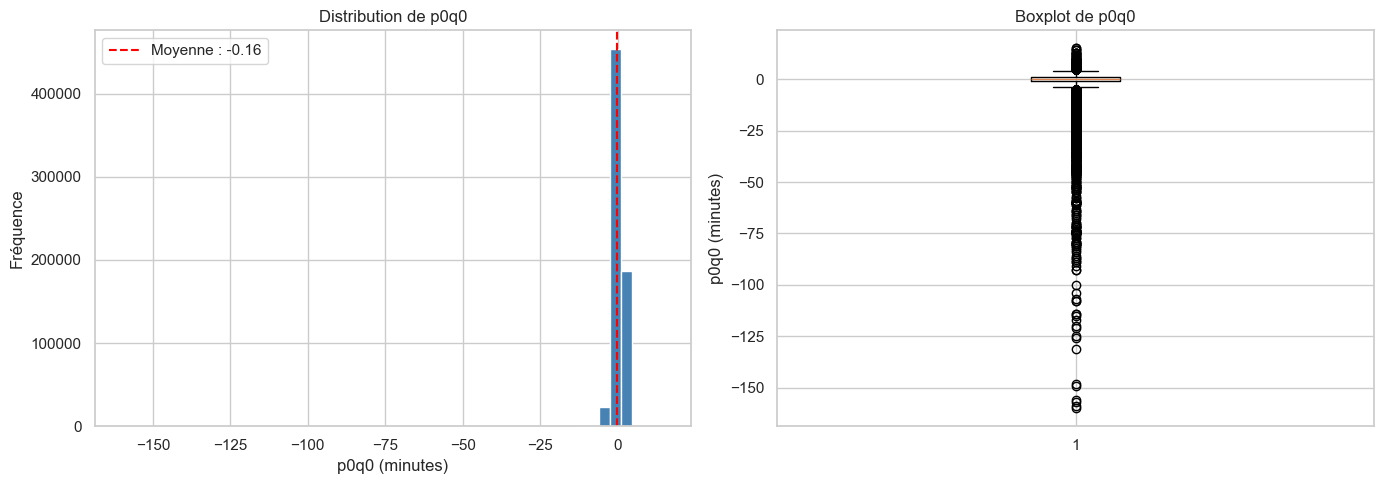

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(y_train['p0q0'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de p0q0')
axes[0].set_xlabel('p0q0 (minutes)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(y_train['p0q0'].mean(), color='red', linestyle='--', label=f"Moyenne : {y_train['p0q0'].mean():.2f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(y_train['p0q0'], vert=True)
axes[1].set_title('Boxplot de p0q0')
axes[1].set_ylabel('p0q0 (minutes)')

plt.tight_layout()
plt.show()

Les trains Transilien sont globalement à l'heure

Il existe des outliers extrêmes (-160 min) qu'on devra gérer

La distribution est très concentrée autour de 0

### 2. Statistiques descriptives


In [8]:
print("=== Statistiques descriptives y_train ===")
display(y_train.describe())

print("\n=== Valeurs uniques de p0q0 ===")
print(f"Nombre de valeurs uniques : {y_train['p0q0'].nunique()}")

print("\nTop 10 valeurs les plus fréquentes :")
print(y_train['p0q0'].value_counts().head(10))

=== Statistiques descriptives y_train ===


,p0q0
count,667264.000000
mean,-0.159950
std,1.987872
min,-160.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,15.000000



=== Valeurs uniques de p0q0 ===
Nombre de valeurs uniques : 120

Top 10 valeurs les plus fréquentes :
p0q0
 0.0    284719
 1.0    144213
-1.0    126077
-2.0     42628
 2.0     29839
-3.0     14559
 3.0     10665
-4.0      4999
-5.0      2365
 4.0      1662
Name: count, dtype: int64


### 3. Analyse des outliers

In [9]:
# Calcul des bornes avec la règle IQR
Q1 = y_train['p0q0'].quantile(0.25)
Q3 = y_train['p0q0'].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

# Détection des outliers
outliers = y_train[(y_train['p0q0'] < borne_inf) | (y_train['p0q0'] > borne_sup)]

print(f"Q1            : {Q1}")
print(f"Q3            : {Q3}")
print(f"IQR           : {IQR}")
print(f"Borne inf     : {borne_inf}")
print(f"Borne sup     : {borne_sup}")
print(f"\nNombre d'outliers : {len(outliers)}")
print(f"Pourcentage       : {len(outliers)/len(y_train)*100:.2f}%")

Q1            : -1.0
Q3            : 1.0
IQR           : 2.0
Borne inf     : -4.0
Borne sup     : 4.0

Nombre d'outliers : 7903
Pourcentage       : 1.18%


## V. Analyse des variables explicatives
### 1. Variables contextuelles

In [10]:
print("=== Variable TRAIN ===")
print(f"Nombre de trains uniques : {x_train['train'].nunique()}")

print("\n=== Variable GARE ===")
print(f"Nombre de gares uniques : {x_train['gare'].nunique()}")

print("\n=== Variable DATE ===")
print(f"Nombre de jours uniques : {x_train['date'].nunique()}")
print(f"Date min : {x_train['date'].min()}")
print(f"Date max : {x_train['date'].max()}")

print("\n=== Variable ARRET ===")
print(f"Min arrêt : {x_train['arret'].min()}")
print(f"Max arrêt : {x_train['arret'].max()}")
print(f"Nombre d'arrêts uniques : {x_train['arret'].nunique()}")

=== Variable TRAIN ===
Nombre de trains uniques : 37544

=== Variable GARE ===
Nombre de gares uniques : 84

=== Variable DATE ===
Nombre de jours uniques : 91
Date min : 2023-04-03
Date max : 2023-11-10

=== Variable ARRET ===
Min arrêt : 7
Max arrêt : 42
Nombre d'arrêts uniques : 36


### 3. Corrélations

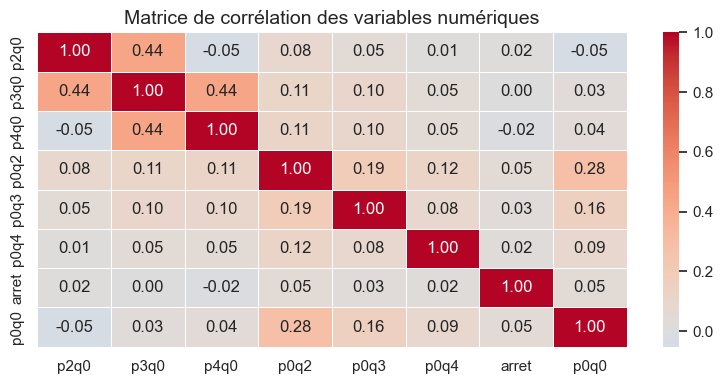

In [ ]:
# Fusion x_train + y_train
df = x_train.copy()
df['p0q0'] = y_train['p0q0'].values

# Sélection des colonnes numériques utiles
cols = ['p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'arret', 'p0q0']

plt.figure(figsize=(8, 4))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

- p0q2 est la variable la plus corrélée avec p0q0 la gare précédente du même train est le meilleur prédicteur !
- Les lags p2q0, p3q0, p4q0 ont une très faible corrélation avec la cible Les corrélations sont toutes faibles  le modèle devra capturer des relations non-linéaires 

## VI. Analyse temporelle
### 1. Analyse par jour de la semaine

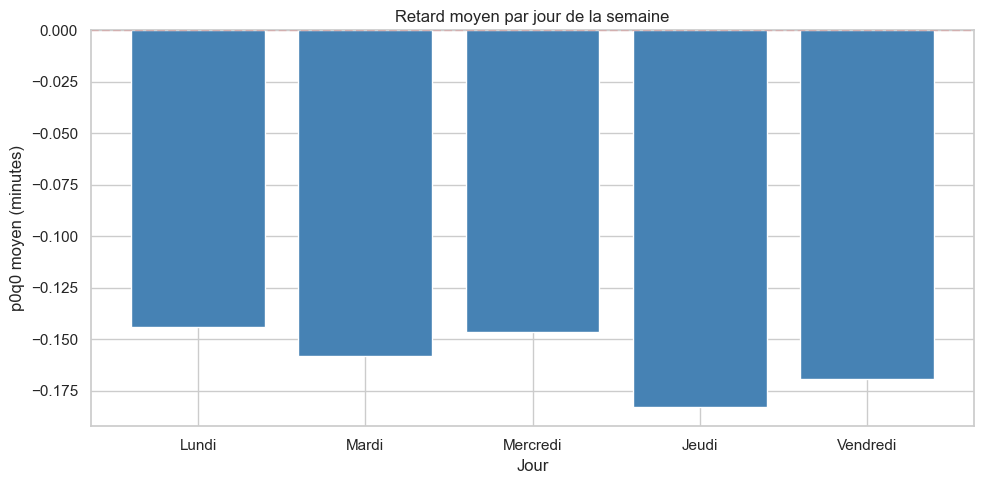

In [ ]:
# Conversion de la date en datetime
df['date'] = pd.to_datetime(df['date'])

# Extraction du jour de la semaine
df['jour_semaine'] = df['date'].dt.dayofweek

# Nom des jours
jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

# Moyenne de p0q0 par jour de la semaine
moyenne_par_jour = df.groupby('jour_semaine')['p0q0'].mean()

# Adapter les jours aux données réelles
jours_presents = [jours[i] for i in moyenne_par_jour.index]

plt.figure(figsize=(10, 5))
plt.bar(jours_presents, moyenne_par_jour.values, color='steelblue', edgecolor='white')
plt.title('Retard moyen par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('p0q0 moyen (minutes)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

- Tous les jours ont un retard négatif (entre -0.145 et -0.18 min)
- Jeudi et Vendredi sont les jours avec le plus de retard (-0.18 min)
- Lundi est le jour le plus ponctuel (-0.145 min)
- Uniquement 5 jours → confirmé : pas de données le week-end !

### 2. Analyse par mois

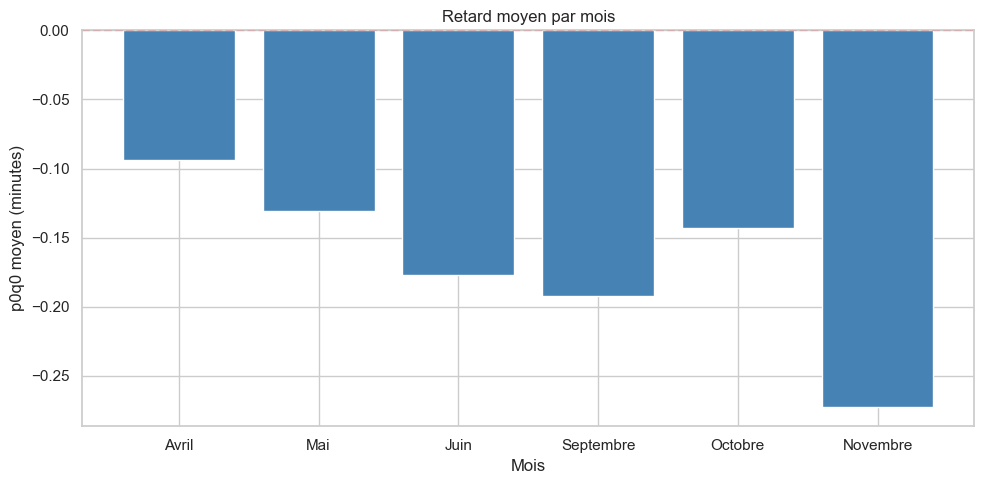

In [ ]:
# Extraction du mois
df['mois'] = df['date'].dt.month

# Nom des mois
mois_noms = {4: 'Avril', 5: 'Mai', 6: 'Juin', 7: 'Juillet', 
             8: 'Août', 9: 'Septembre', 10: 'Octobre', 11: 'Novembre'}

# Moyenne de p0q0 par mois
moyenne_par_mois = df.groupby('mois')['p0q0'].mean()

plt.figure(figsize=(10, 5))
plt.bar(
    [mois_noms[m] for m in moyenne_par_mois.index],
    moyenne_par_mois.values,
    color='steelblue',
    edgecolor='white'
)
plt.title('Retard moyen par mois')
plt.xlabel('Mois')
plt.ylabel('p0q0 moyen (minutes)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

- Avril est le mois le plus ponctuel -> début de période, météo clémente
- Novembre est le pire mois -> automne, mauvaise météo, plus de voyageurs
- Juillet/Août manquent -> pas de données en été (vacances scolaires ?)
- La tendance générale -> les retards augmentent en automne 

### 3. Analyse par gare

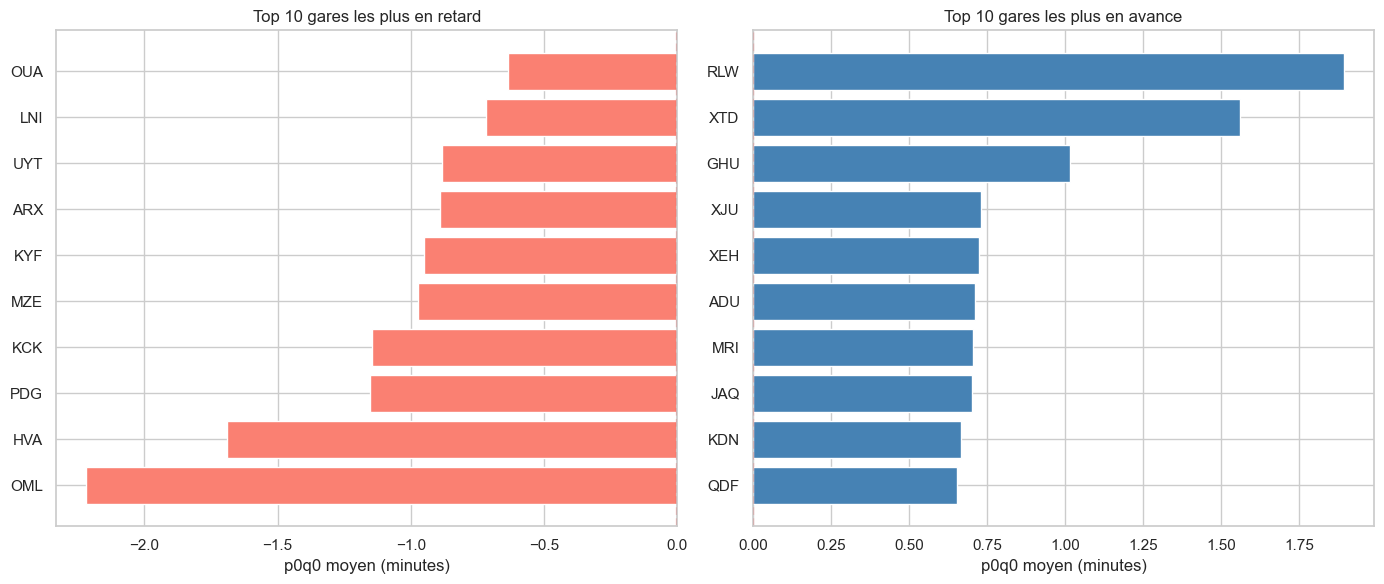

In [ ]:
# Moyenne de p0q0 par gare
moyenne_par_gare = df.groupby('gare')['p0q0'].mean().sort_values()

# Top 10 gares les plus en retard et les plus en avance
top10_retard = moyenne_par_gare.head(10)
top10_avance = moyenne_par_gare.tail(10)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gares les plus en retard
axes[0].barh(top10_retard.index, top10_retard.values, color='salmon', edgecolor='white')
axes[0].set_title('Top 10 gares les plus en retard')
axes[0].set_xlabel('p0q0 moyen (minutes)')
axes[0].axvline(0, color='red', linestyle='--')

# Gares les plus en avance
axes[1].barh(top10_avance.index, top10_avance.values, color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 gares les plus en avance')
axes[1].set_xlabel('p0q0 moyen (minutes)')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

- La gare influence clairement le retard -> c'est une variable très importante pour notre modèle !
- rtaines gares sont structurellement en retard (OML, HVA) -> probablement des gares avec beaucoup de trafic ou des contraintes techniques
- On devra créer une feature "retard moyen par gare" lors du feature engineering !

### 4. Analyse par train 

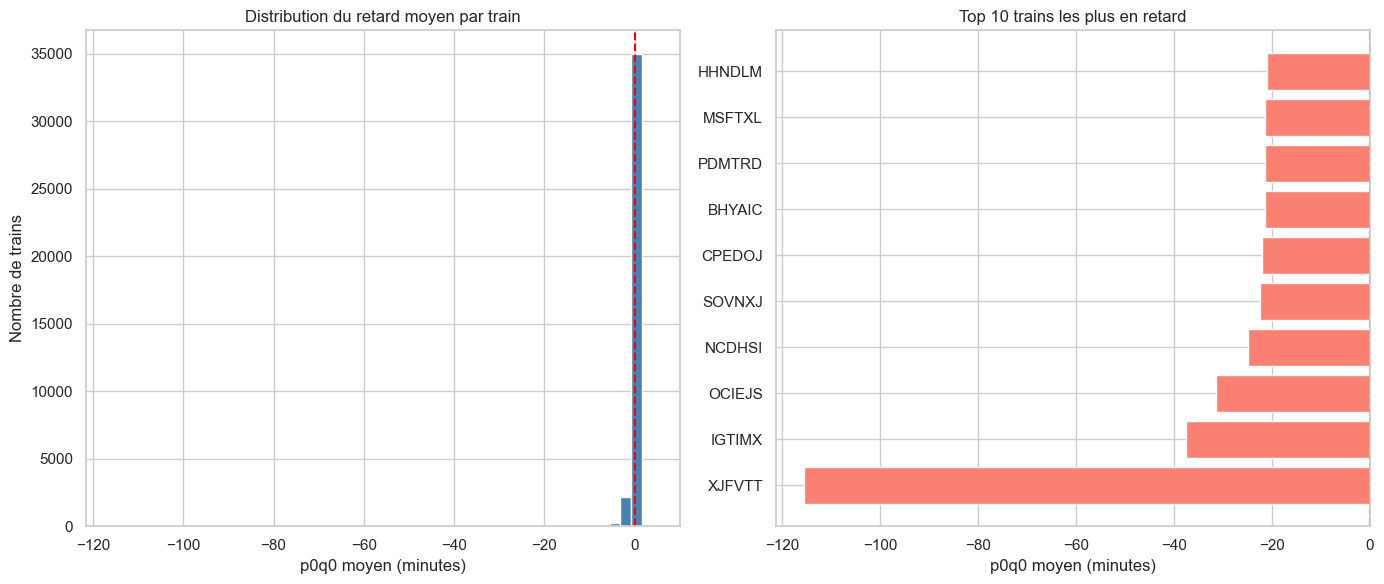

In [20]:
# Moyenne de p0q0 par train
moyenne_par_train = df.groupby('train')['p0q0'].mean().sort_values()

# Top 10 trains les plus en retard et les plus en avance
top10_retard_train = moyenne_par_train.head(10)
top10_avance_train = moyenne_par_train.tail(10)

# Distribution des moyennes par train
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogramme de la moyenne par train
axes[0].hist(moyenne_par_train.values, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du retard moyen par train')
axes[0].set_xlabel('p0q0 moyen (minutes)')
axes[0].set_ylabel('Nombre de trains')
axes[0].axvline(0, color='red', linestyle='--')

# Top 10 trains les plus en retard
axes[1].barh(top10_retard_train.index, top10_retard_train.values, color='salmon', edgecolor='white')
axes[1].set_title('Top 10 trains les plus en retard')
axes[1].set_xlabel('p0q0 moyen (minutes)')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

- XJFVTT est clairement un outlier — probablement un train qui a eu un incident grave (panne, accident)
- Ces trains extrêmes fausseront notre modèle -> on devra les gérer avec le clipping
- La variable train est importante mais avec 37 544 valeurs uniques, il faudra l'encoder intelligemment

### 5. Analyse par numéro d'arrêt

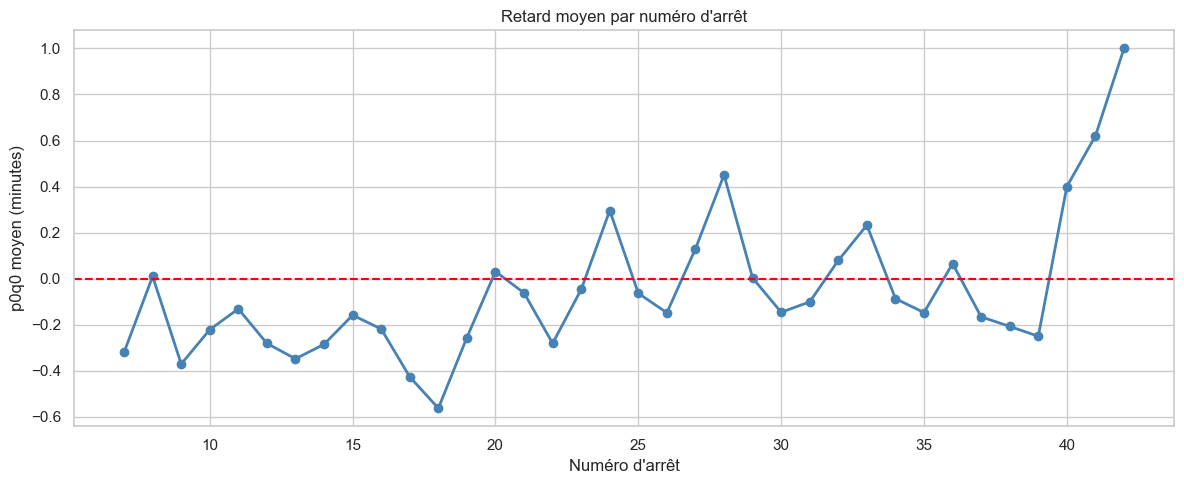

In [17]:
# Moyenne de p0q0 par numéro d'arrêt
moyenne_par_arret = df.groupby('arret')['p0q0'].mean()

# Visualisation
plt.figure(figsize=(12, 5))
plt.plot(moyenne_par_arret.index, moyenne_par_arret.values, 
         color='steelblue', marker='o', linewidth=2)
plt.title('Retard moyen par numéro d\'arrêt')
plt.xlabel('Numéro d\'arrêt')
plt.ylabel('p0q0 moyen (minutes)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

- Début du trajet (arrêts 7-18) → les trains sont en retard — ils accumulent du retard au début
- Milieu du trajet (arrêts 20-35) → les trains rattrapent leur retard progressivement
- Fin du trajet (arrêts 40-42) → les trains arrivent en avance → le conducteur accélère pour rattraper le temps perdu !

## VII. Analyse en Composantes Principales (PCA)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sélection des variables numériques
cols_pca = ['p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'arret']

# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols_pca])

# Application de la PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée par chaque composante
variance_expliquee = pca.explained_variance_ratio_ * 100
variance_cumulee = np.cumsum(variance_expliquee)

print("=== Variance expliquée par composante ===")
for i, v in enumerate(variance_expliquee):
    print(f"PC{i+1} : {v:.2f}%  (cumulé : {variance_cumulee[i]:.2f}%)")

=== Variance expliquée par composante ===
PC1 : 24.49%  (cumulé : 24.49%)
PC2 : 16.81%  (cumulé : 41.31%)
PC3 : 15.14%  (cumulé : 56.44%)
PC4 : 13.88%  (cumulé : 70.33%)
PC5 : 13.22%  (cumulé : 83.54%)
PC6 : 11.43%  (cumulé : 94.97%)
PC7 : 5.03%  (cumulé : 100.00%)


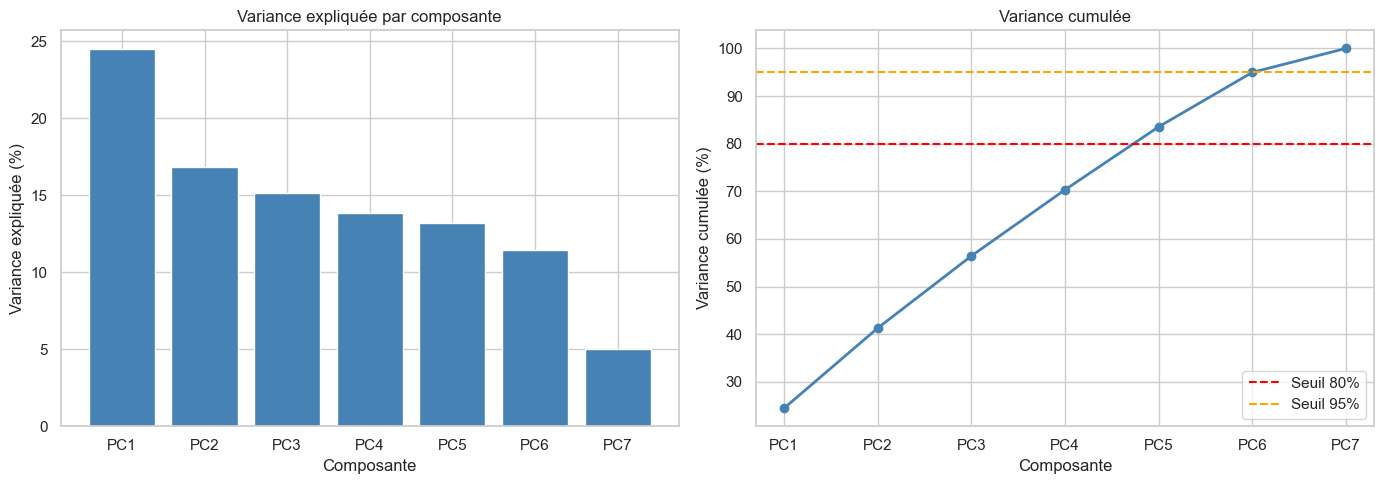

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Variance expliquée par composante
axes[0].bar(
    [f'PC{i+1}' for i in range(len(variance_expliquee))],
    variance_expliquee,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Variance expliquée par composante')
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée (%)')

# Graphique 2 : Variance cumulée
axes[1].plot(
    [f'PC{i+1}' for i in range(len(variance_cumulee))],
    variance_cumulee,
    color='steelblue',
    marker='o',
    linewidth=2
)
axes[1].axhline(80, color='red', linestyle='--', label='Seuil 80%')
axes[1].axhline(95, color='orange', linestyle='--', label='Seuil 95%')
axes[1].set_title('Variance cumulée')
axes[1].set_xlabel('Composante')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

- Il faut 5 composantes pour garder 80% de l'information
- Il faut 6 composantes pour garder 95% de l'information
- L'information est bien répartie → aucune variable ne domine
- Dans notre projet on n'utilisera pas la PCA pour le modèle car on a peu de variables — mais c'est une bonne pratique de l'analyser 

## VIII. Conclusions de l'EDA

### Observations clés

####  Données propres
- 0 valeur manquante dans tous les datasets
- 667 264 lignes d'entraînement, 20 657 lignes de test

####  Variable cible (p0q0)
- 42% des trains arrivent exactement à l'heure (p0q0 = 0)
- 50% des trains entre -1 et +1 minute
- Outliers : 7 903 cas (1.18%) jusqu'à -160 min → clipping [-4, +4]

####  Analyse temporelle
- Données du 03/04/2023 au 10/11/2023 (91 jours, lundi→vendredi)
- Novembre = mois le plus en retard (-0.26 min)
- Jeudi et Vendredi = jours les plus en retard

####  Analyse par gare
- 84 gares uniques
- Gare OML = plus en retard (-2.0 min)
- Gare RLW = plus en avance (+1.9 min)

####  Analyse par train
- 37 544 trains uniques
- Certains trains ont des incidents exceptionnels (ex: XJFVTT = -115 min sur 2 arrêts)

####  Actions pour le Feature Engineering
- Convertir `date` en datetime → extraire jour, mois, jour de semaine
- Clipping outliers entre [-4, +4]
- Encoder `train` et `gare` (Target Encoding)
- Créer feature "retard moyen par gare"
- Créer feature "retard moyen par train"